In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")

# First look
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# Keep only the relevant columns and rename them
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Remove duplicate messages
df = df.drop_duplicates(keep='first')

# Encode labels: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.shape)
df.head()


(5169, 3)


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [5]:
df.to_csv("../data/processed/cleaned_data.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.


C:\Users\tousi\AppData\Local\Temp\ipykernel_9800\1904622033.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#4C72B0', '#DD8452'])


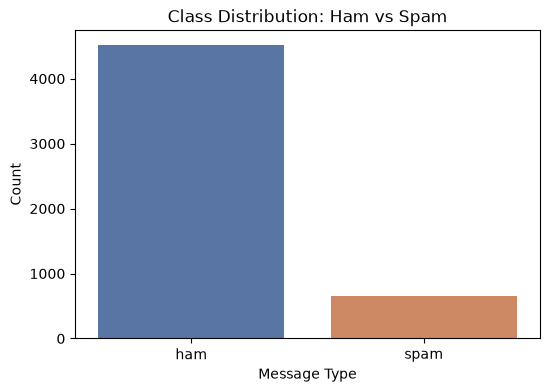

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Class Distribution: Ham vs Spam')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.savefig("../images/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

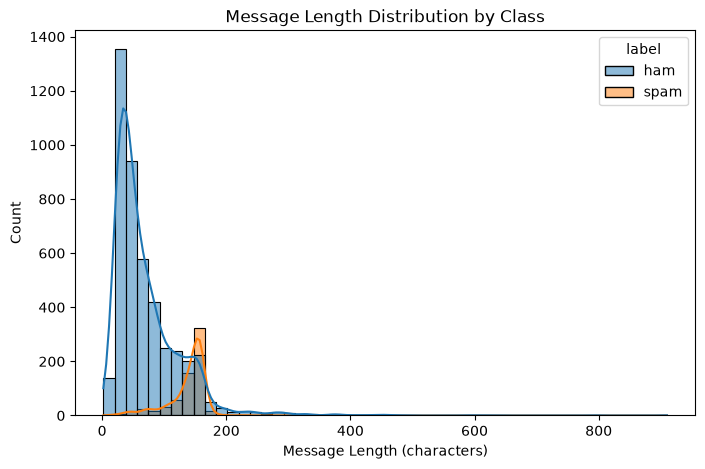

In [7]:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution by Class')
plt.xlabel('Message Length (characters)')
plt.savefig("../images/message_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_message'] = df['message'].apply(clean_text)
df.sample(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tousi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,message,label_num,message_length,clean_message
4124,ham,May b approve panalam...but it should have mor...,0,55,may b approv panalambut post
4716,ham,"K will do, addie &amp; I are doing some art so...",0,77,k addi amp art ill get home
1855,ham,K.:)you are the only girl waiting in reception...,0,50,kyou girl wait recept ah
4523,ham,I've sent Ì_ my part..,0,22,ive sent part
4061,ham,Hi dear we saw dear. We both are happy. Where ...,0,67,hi dear saw dear happi batteri low
2351,spam,Download as many ringtones as u like no restri...,1,120,download mani rington u like restrict choos u ...
1164,ham,Well. Im computerless. Time to make some oreo ...,0,54,well im computerless time make oreo truffl
4794,ham,Saw Guys and Dolls last night with Patrick Swa...,0,62,saw guy doll last night patrick swayz great
2068,ham,Its hard to believe things like this. All can ...,0,99,hard believ thing like say lie think twice say...
3449,ham,Ya just telling abt tht incident..,0,34,ya tell abt tht incid


C:\Users\tousi\AppData\Local\Temp\ipykernel_9800\2451828298.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='Reds_r')


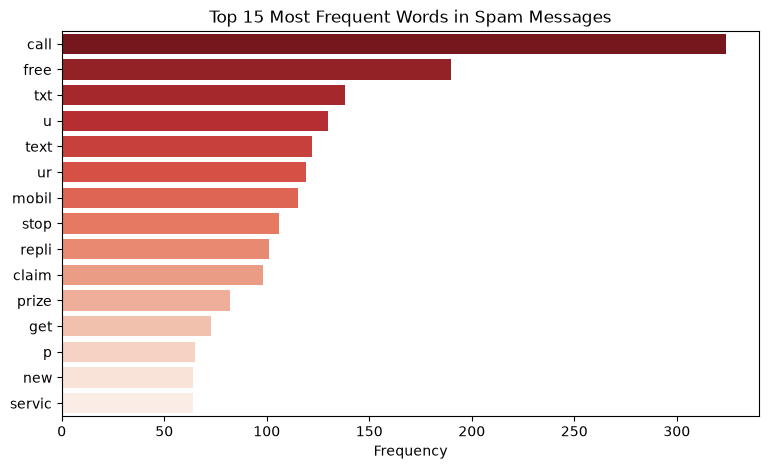

In [12]:
from collections import Counter

spam_words = ' '.join(df[df['label'] == 'spam']['clean_message']).split()
top_spam = Counter(spam_words).most_common(15)

words, counts = zip(*top_spam)

plt.figure(figsize=(9,5))
sns.barplot(x=list(counts), y=list(words), palette='Reds_r')
plt.title('Top 15 Most Frequent Words in Spam Messages')
plt.xlabel('Frequency')
plt.savefig("../images/top_spam_words.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 4135, Test size: 1034


In [14]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Vocabulary size: 6117


In [15]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)
print("Model trained successfully.")

Model trained successfully.


In [16]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Accuracy: 0.9806576402321083

Classification Report:
               precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.94      0.90      0.92       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



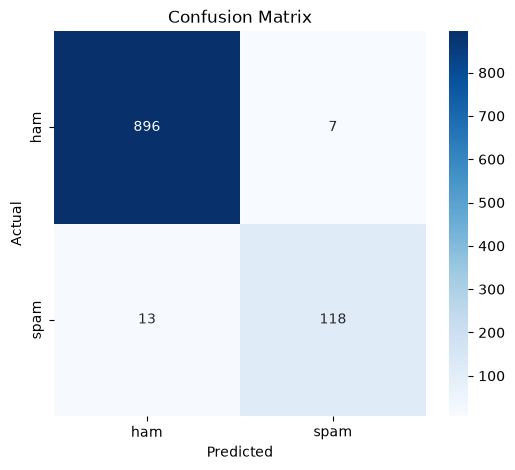

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

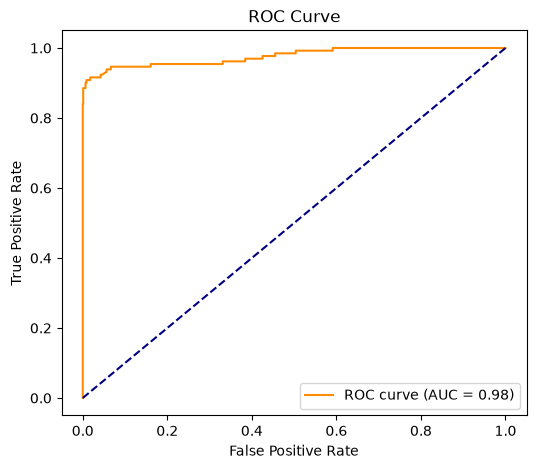

In [18]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_vec)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
import joblib

joblib.dump(model, "../models/naive_bayes_model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
print("Model and vectorizer saved.")

Model and vectorizer saved.
